# Figures for Section 5 from Nicolas & Vallis (2026): Mechanisms of Superrotation in Slowly-Rotating and Tidally-Locked Planets

Use this notebook to reproduce figures 13-14 from the paper. The notebook requires output from two-level simulations of tidally locked planets.
See README.md for how to run these simulations.

In [1]:
import numpy as np
import xarray as xr
from scipy.ndimage import gaussian_filter1d
import os

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.path as mpath
import cartopy.crs as ccrs

from emfcTools import calc_emfc, calc_emfc_tmean, get_emfc_spectra_nondim_zeta
from processingTools import open_h5s_wgauge
from plottingTools import plot_map, filter_mode, add_ticks

%load_ext autoreload
%autoreload 2

In [2]:
# Adapt to your local setup
SNAPSHOTS_DIR = '/Users/qnicolas/superrotation/data/' 

# Data

In [3]:
def prep_sim(sim,Ro_T):
    sim['theta1_tmean'] = sim.theta1.mean('t')
    sim['u1_tmean']     = sim.u1.mean('t')
    sim['u1x_tmean']    = sim['u1_tmean'].mean('longitude')[0]
    
    calc_emfc(sim,Ro_T)
    sim['mmc'] = sim['mmc'].mean('t')
    sim['emfc'] = sim['emfc'].mean('t')
    calc_emfc_tmean(sim,Ro_T)
    
    cospec = get_emfc_spectra_nondim_zeta(sim,Ro_T)
    sim['cospec'] = cospec


In [4]:
T64_2lev_transition={}
Ro_T = 10
tau_rad_nondim = 250
# `lontyp` sets the longitudinal structure of the forcing. `axi` is axisymmetric (epsilon=0), `suarezpXX` is epsilon=0.05, 0.1, 0.25, 
# `semilocked` is epsilon=0.5, and `locked` is the full "truncated cosine" forcing
lontyps = ['axi','suarezp05','suarezp1','suarezp25','semilocked','locked']

for lontyp in lontyps:
    snapshot_id = f'snapshots_2levelnondim_T64_{lontyp}_{Ro_T:.2f}_0p02_{tau_rad_nondim}_0p05'
    snapshot_id = snapshot_id.replace('.','p')
    snapshot = xr.open_dataset(SNAPSHOTS_DIR+"transition/%s.nc"%snapshot_id)

    prep_sim(snapshot, Ro_T)
    T64_2lev_transition[lontyp] = snapshot.sel(t=slice(300 * 4 * np.pi,None))

[iacmac-ds4973:39657] shmem: mmap: an error occurred while determining whether or not /var/folders/g5/y1nh4h6x3j3c3lh5frsdkvtc0000gq/T//ompi.iacmac-ds4973.503/jf.0/1294139392/sm_segment.iacmac-ds4973.503.4d230000.0 could be created.


The following is needed to exactly reproduce Figures 14. 
It requires simulations with high-temporal-resolution output of EMFC terms. 

If not available the EMFC plots are simply a bit more noisy.

In [5]:
def calc_emfc_sim_avg(sim, Ro_T):
    tmean = lambda x: (x.isel(t=-1) - x.isel(t=0)) / (sim.t[-1] - sim.t[0])
    prime = lambda x: x - x.mean('longitude')

    sim['mmc'] = tmean(sim['fv1_avg']) + Ro_T * tmean(sim.v1_avg).mean('longitude') * tmean(sim.zeta1_avg).mean('longitude') + Ro_T * tmean(sim.omega_avg).mean('longitude') * tmean(sim.u1mu2_avg).mean('longitude')
    sim['emfc_tmean'] = Ro_T * ( prime(tmean(sim.v1_avg)) * prime(tmean(sim.zeta1_avg)) + prime(tmean(sim.omega_avg)) * prime(tmean(sim.u1mu2_avg)) ).mean('longitude')
    sim['emfc_transients'] = tmean(sim['fv1_avg']+sim['eddy_avg']) - sim['mmc'] - sim['emfc_tmean']
    sim['hyperdiff_tmean'] = tmean(sim['hyperdiff_avg'])


for lontyp in lontyps:
    snapshot_id = f'snapshots_2levelnondim_T64_{lontyp}_{Ro_T:.2f}_0p02_{tau_rad_nondim}_0p05'
    snapshot_id = snapshot_id.replace('.','p')
    snapshot_fulloutput = xr.open_dataset(SNAPSHOTS_DIR + "transition/%s_averages.nc"%snapshot_id)
    for var in ['fv1_avg','eddy_avg','hyperdiff_avg']:
        snapshot_fulloutput[var] = snapshot_fulloutput[var].isel(longitude=0)
    calc_emfc_sim_avg(snapshot_fulloutput, Ro_T)
    T64_2lev_transition[lontyp,"averages"] = snapshot_fulloutput.sel(t=slice(300 * 4 * np.pi,None))


# Zonal-mean zonal wind

In [6]:
def pad_lat(ds):
    """Add missing latitude points at the poles"""
    lat = 'latitude'
    return ds.pad({lat:1}, mode='constant', constant_values = 0.).assign_coords({lat:np.concatenate([[-90.],ds[lat].values, [90.]])})

axi
suarezp05
suarezp1
suarezp25
semilocked
locked


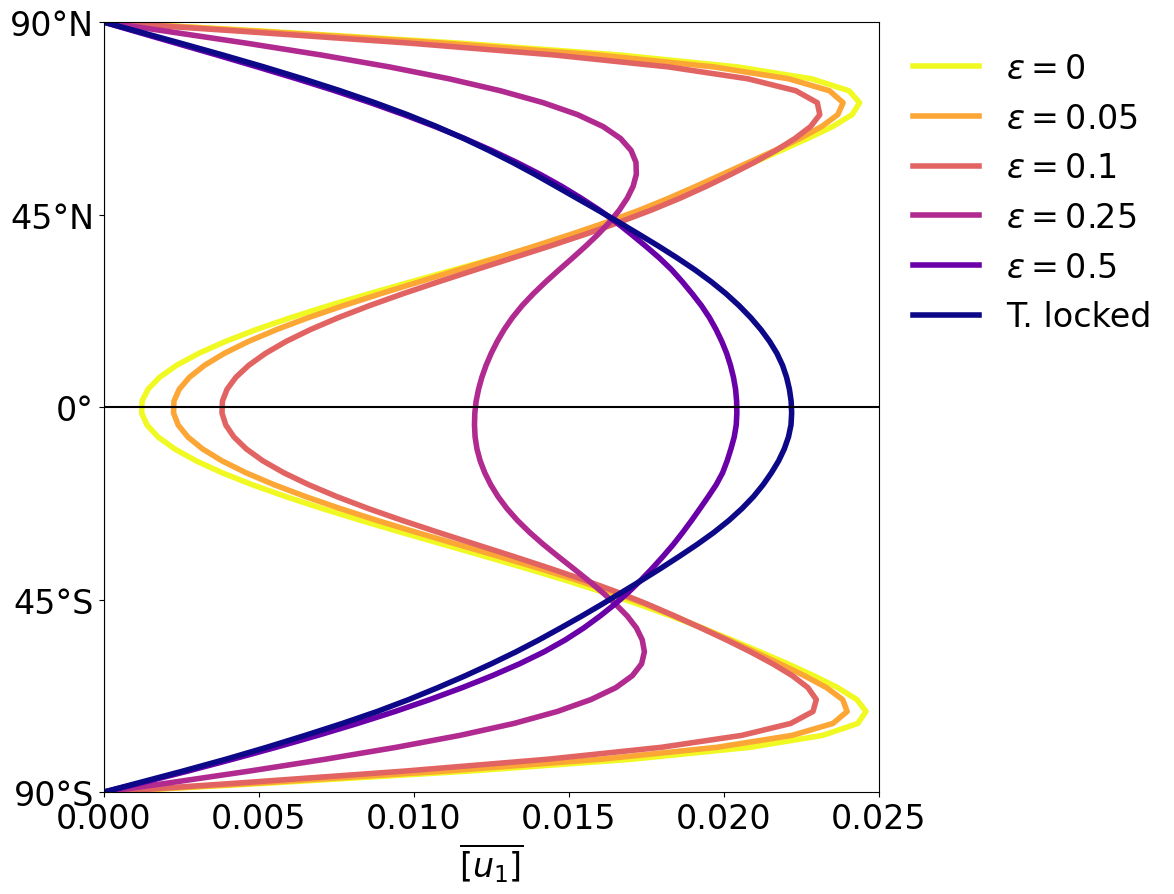

In [7]:
matplotlib.rcParams['font.size'] = 24

fig,ax=plt.subplots(1,1,figsize=(10,10))

keys = list(T64_2lev_transition.keys())[:5] + ['locked2']
colors = plt.cm.plasma_r(np.linspace(0,1,len(keys)))
lbls = [r'$\epsilon=0$',
        r'$\epsilon=0.05$',
        r'$\epsilon=0.1$',
        r'$\epsilon=0.25$',
        r'$\epsilon=0.5$',
        r'T. locked',
        ]

for i,key in enumerate(lontyps):
    print(key)
    sim = T64_2lev_transition[key]
    pad_lat(sim.u1x_tmean).plot(ax=ax,color=colors[i],y='latitude',linewidth=4,label=lbls[i])

# Axis cosmetucs
ax.set_ylim(-90,90)
ax.axvline(0.,color='k')
ax.axhline(0.,color='k')
# position legend to the right
ax.legend(bbox_to_anchor=(1.005, 1), loc='upper left',frameon=False)
ax.set_xlabel(r'$\overline{[u_1]}$')
ax.set_ylabel('')
ax.set_yticks(np.arange(-90,91,45))
ax.set_yticklabels(['90°S','45°S','0°','45°N','90°N'])
ax.set_xlim(0.,0.025)
fig.savefig('figs/utransition.pdf',format='pdf',bbox_inches='tight')

# EMFC plot

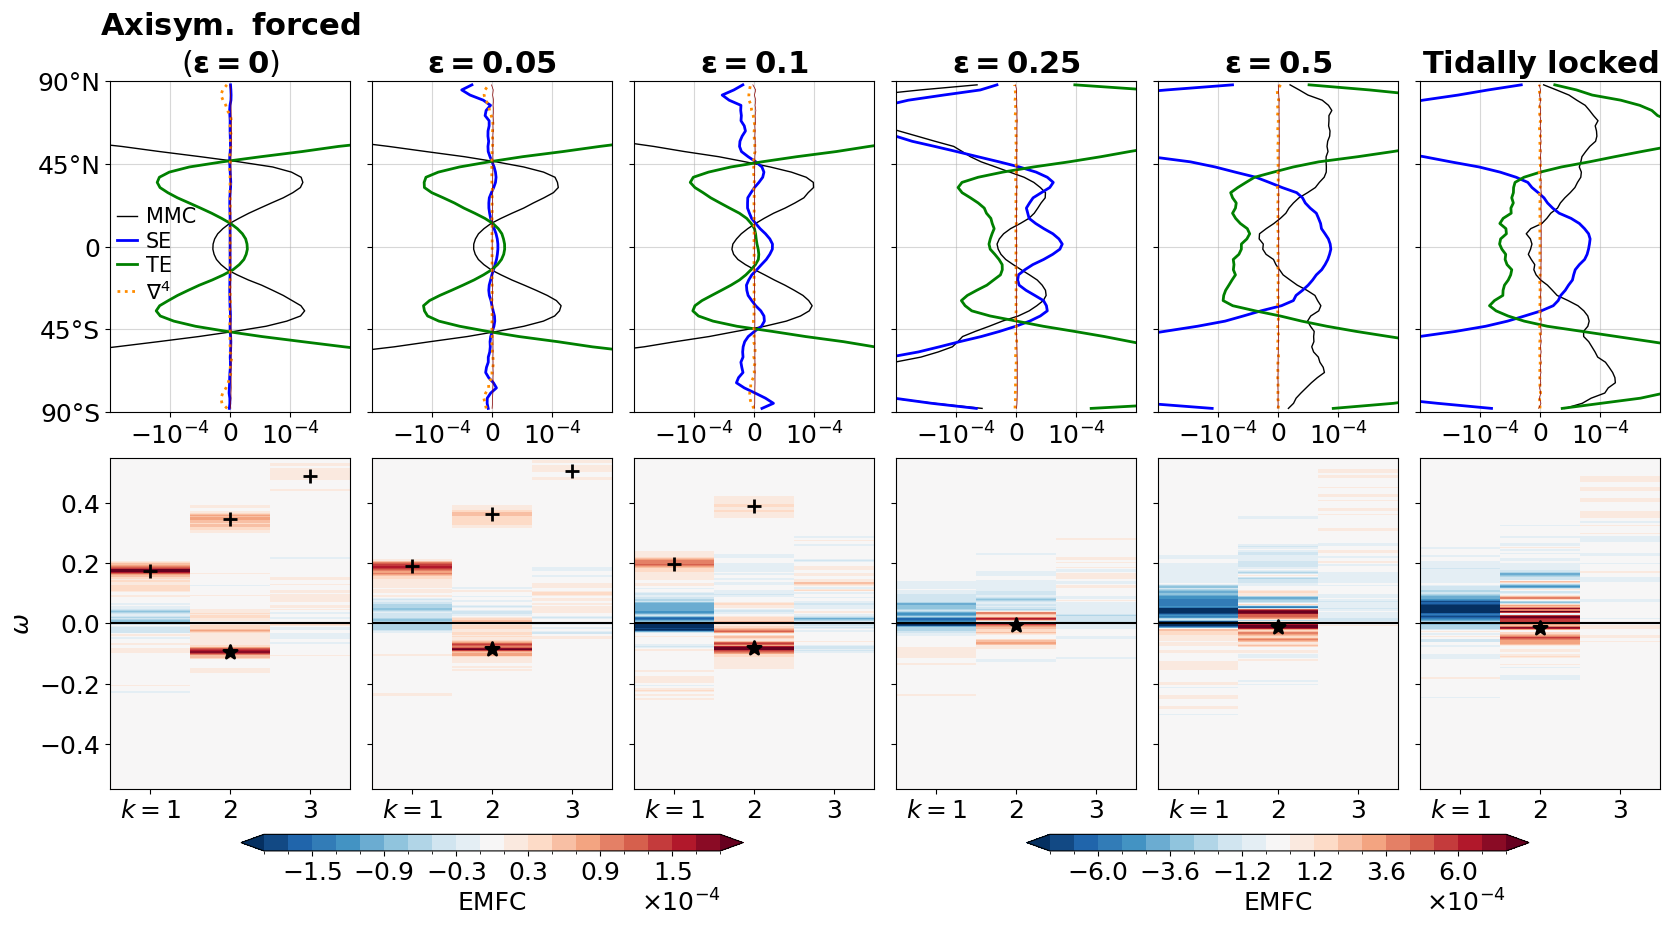

In [8]:
matplotlib.rcParams.update({'font.size':18})

fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 12, figure=fig,height_ratios=[1,1,0.05],wspace=0.2)
axs = np.array([[fig.add_subplot(gs[i, 2*j:2*j+2]) for j in range(6)] for i in range(2)])
axcbar1 = fig.add_subplot(gs[2,1:5])
axcbar2 = fig.add_subplot(gs[2,7:11])

lbls = [r'$\mathbf{Axisym.~forced}$'  + '\n' + r'$(\mathbf{\epsilon=0})$',
        r'$\mathbf{\epsilon=0.05}$',
        r'$\mathbf{\epsilon=0.1}$',
        r'$\mathbf{\epsilon=0.25}$',
        r'$\mathbf{\epsilon=0.5}$',
        r'$\mathbf{Tidally~locked}$',
        ]

for i,key in enumerate(lontyps):
    ######## Top row:  zonal-mean zonal momentum budget ########
    ax=axs[0,i]
    sim = T64_2lev_transition[key]

    try:
        sim_avg = T64_2lev_transition[key,'averages']
        hyperdiff_desc = r'$\nabla^4$'
    except KeyError:
        print(f"WARNING: No high-temporal-resolution output for lontyp={lontyps}: EMFC plots will be more noisy")
        sim_avg = sim
        sim_avg['emfc_transients'] = sim_avg['emfc'] - sim_avg['emfc_tmean']
        sim_avg['hyperdiff_tmean'] = -(sim_avg['emfc'] + sim_avg['mmc'])
        hyperdiff_desc = "unresolved transients + "r'$\nabla^4$'

    sim_avg.mmc             .plot(ax=ax, y='latitude',color='k',linewidth=1.,label = 'MMC')
    sim_avg.emfc_tmean      .plot(ax=ax, y='latitude',color='b',linewidth=2.,label = 'SE')
    sim_avg.emfc_transients .plot(ax=ax, y='latitude',color='g',linestyle='-',linewidth=2,label='TE')    
    (-sim_avg.hyperdiff_tmean).plot(ax=ax, y='latitude',color='darkorange',linestyle=':',linewidth=2,label=hyperdiff_desc)    
    (sim_avg.mmc + sim_avg.emfc_tmean + sim_avg.emfc_transients - sim_avg.hyperdiff_tmean)  .plot(ax=ax,y='latitude',color='darkred',linewidth=.5)

    # Axis cosmetics
    MM = 2e-4 
    ax.set_xlim(-MM,MM)
    ax.set_ylim(-90,90)
    ax.grid(alpha=.5)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(range(-90,91,45))
    ax.set_yticklabels([r'90°S',r'45°S',r'$0$',r'45°N',r'90°N'])
    ax.set_xticks([-1e-4,0,1e-4])
    ax.set_xticklabels([r"$-10^{-4}$",r'$0$',r'$10^{-4}$'])

    ax.set_title(lbls[i],fontweight='bold',fontsize=22)

    ######### Bottom row: EMFC cospectra #########
    ax=axs[1,i]

    plot = (sim.cospec * (sim.cospec.frequency != 0)).sel(latitude=slice(-10,10)).mean('latitude')
    plot = (gaussian_filter1d(plot,7.,axis=0)*plot**0)

    if i<3:
        MM = 2e-4
        c1 = plot.plot(ax=ax,y='frequency',levels=np.arange(-MM+MM/20,MM,MM/10),extend='both',add_colorbar=False)
    else:
        MM = 8e-4
        c2 = plot.plot(ax=ax,y='frequency',levels=np.arange(-MM+MM/20,MM,MM/10),extend='both',add_colorbar=False)
    
    # Label modes on graph
    # RK modes
    if i < 2:
        mode_numbers = [1,2,3] 
    elif i == 2:
        mode_numbers = [1,2]
    else:
        mode_numbers = [1]
    if i < 3 :#or i==5:
        ax.scatter(mode_numbers,
                   [plot.frequency[plot.sel(kphi=i).where(plot.frequency>0.15).argmax()] for i in mode_numbers],
                   marker='+',color='k',s=100,linewidths=[2])
        
    # MRG modes
    ax.scatter([2],
                [plot.frequency[plot.sel(kphi=2).where(plot.frequency<0).argmax()]],
                marker='*',color='k',s=100,linewidths=[2])
        
    # Axis cosmetics
    ax.set_xlim(0.5,3.5)
    ax.set_ylim(-0.55,0.55)
    ax.axhline(0,color='k',ls='-')
    ax.set_ylabel(r"$\omega$")
    ax.set_xlabel('')
    ax.set_xticks([1,2,3])
    ax.set_xticklabels([r"$k=1$", r"$2$", r"$3$"])

    if i > 0:
        axs[0,i].set_ylabel('')
        axs[0,i].set_yticklabels('')
        axs[1,i].set_ylabel('')
        axs[1,i].set_yticklabels('')

for c,axcbar,MM in zip([c1,c2],[axcbar1,axcbar2],[2e-4,8e-4]):
    cb = fig.colorbar(c, cax=axcbar, orientation='horizontal',label=r'EMFC', ticks = np.arange(-0.75*MM,MM,0.3*MM))
    cb.formatter.set_powerlimits((0, 0))
    cb.formatter.set_useMathText(True)
    
# legend with smaller line lengths
axs[0,0].legend(loc = (0.01,0.32), handlelength=1, borderpad=0.2,borderaxespad=0.1,handletextpad=0.4,fontsize=15,labelspacing = 0.2,frameon=False)#,ncol=2)#,columnspacing=0.8)
                
# fig.savefig('figs/emfc_transition.png',format='png',bbox_inches='tight', dpi=600)